# LightGBM

## 1. Imports

In [3]:
import math
import os
import pickle
import re
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from matplotlib.patches import Patch
from sklearn import metrics
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


## 2. Settings

In [6]:
DATA_FILE = "DatasetIPMM3.xlsx"
OUTPUT_DIR = Path("Light GBM")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_COL = "Capacitance"
MONOMER_COL = "Monomer"
POLYMER_COL = "Polymer_Type"

RANDOM_STATE_SPLIT = 100
RANDOM_STATE_MODEL = 42
TEST_SIZE = 0.20
USE_STRATIFIED_SPLIT = False
REUSE_EXISTING_SPLIT_FILE = False
SPLIT_FILE_CANDIDATES = [
    Path("Light GBM") / "Data_Split_Assignment.xlsx",
    Path("LGBM_combined_PANI_PPy_SHAP_fixed_outputs") / "Data_Split_Assignment.xlsx",
    Path("Data_Split_Assignment.xlsx"),
]

CV_MODE = "original"
CV_SPLITS = 5
ALPHA_OVERFIT_GAP = 1.0

RUN_GRID_SEARCH = True
GRID_VERBOSE = 2
GRID_N_JOBS = -1

WRITE_PER_FEATURE_SHAP_PLOTS = True
RUN_PDP2D_INTERACTIONS = True
MIN_CELL_N_FOR_SUPPORTED_PDP2D = 5
MAX_NUMERIC_GRID_VALUES = 15
MIN_VALUE_COUNT_FOR_NUMERIC_GRID = 3

numerical_features = [
    "OMR", "SSA", "AMR", "BR", "CR", "ACN", "Molarity", "PW", "CD"
]
categorical_features = [
    "Monomer", "Dopant", "Template", "Oxidant", "Electrolyteclass", "Configuration"
]
feature_names = numerical_features + categorical_features


## 3. Helper functions

In [9]:
def clean_filename(text):
    text = str(text).strip()
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    return text[:120]


def polymer_type_from_monomer(value):
    s = str(value).strip()
    key = s.lower().replace(" ", "").replace("-", "").replace("_", "")
    if key in {"aniline", "anilin", "pani", "polyaniline", "polyanilin"}:
        return "PANI"
    if key in {"pyrrole", "pyrole", "ppy", "polypyrrole", "polypyrole"}:
        return "PPy"
    return s if s else "Unknown"


def require_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"These required columns are missing from the Excel file: {missing}")


def load_and_prepare_dataset(path):
    df = pd.read_excel(path)
    require_columns(df, feature_names + [TARGET_COL])

    df = df.copy()
    df.insert(0, "Original_Row_Index", df.index)
    df.insert(1, "Excel_Row", df["Original_Row_Index"] + 2)
    df.insert(2, "Record_ID", np.arange(1, len(df) + 1))

    for col in numerical_features + [TARGET_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in categorical_features:
        df[col] = df[col].astype("string").fillna("Missing").str.strip()
        df[col] = df[col].replace({"nan": "Missing", "None": "Missing", "": "Missing"})

    df[POLYMER_COL] = df[MONOMER_COL].apply(polymer_type_from_monomer)

    before = len(df)
    df = df.dropna(subset=numerical_features + [TARGET_COL]).reset_index(drop=True)
    after = len(df)
    if before != after:
        print(f"Dropped {before - after} rows with missing numerical feature or target values.")

    for col in categorical_features:
        df[col] = df[col].astype("category")

    return df


def make_stratification_labels(df, y, q=5):
    labels_polymer = df[POLYMER_COL].astype(str)
    try:
        bins = pd.qcut(y, q=q, duplicates="drop").astype(str)
        labels = labels_polymer + "_" + bins
        if labels.value_counts().min() >= 2:
            return labels
    except Exception:
        pass

    if labels_polymer.value_counts().min() >= 2:
        return labels_polymer
    return None


def safe_train_test_split_indices(df, y):
    all_idx = np.arange(len(df))

    if REUSE_EXISTING_SPLIT_FILE:
        for split_path in SPLIT_FILE_CANDIDATES:
            if not split_path.exists():
                continue
            try:
                split_df = pd.read_excel(split_path)
                if "Split" not in split_df.columns:
                    continue

                train_idx = test_idx = None
                if "Record_ID" in split_df.columns and "Record_ID" in df.columns:
                    test_record_ids = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("test"), "Record_ID"].astype(int))
                    train_record_ids = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("train"), "Record_ID"].astype(int))
                    test_idx = df.index[df["Record_ID"].astype(int).isin(test_record_ids)].to_numpy()
                    train_idx = df.index[df["Record_ID"].astype(int).isin(train_record_ids)].to_numpy()

                if (train_idx is None or len(train_idx) == 0 or len(test_idx) == 0) and "Original_Row_Index" in split_df.columns:
                    test_original = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("test"), "Original_Row_Index"].astype(int))
                    train_original = set(split_df.loc[split_df["Split"].astype(str).str.lower().eq("train"), "Original_Row_Index"].astype(int))
                    test_idx = df.index[df["Original_Row_Index"].astype(int).isin(test_original)].to_numpy()
                    train_idx = df.index[df["Original_Row_Index"].astype(int).isin(train_original)].to_numpy()

                if train_idx is not None and len(train_idx) > 0 and len(test_idx) > 0 and len(train_idx) + len(test_idx) == len(df):
                    return train_idx, test_idx, f"Reused existing split file: {split_path}"
            except Exception as exc:
                print(f"Could not reuse split file {split_path}: {exc}")

    if USE_STRATIFIED_SPLIT:
        stratify_labels = make_stratification_labels(df, y, q=5)
        if stratify_labels is not None:
            train_idx, test_idx = train_test_split(
                all_idx,
                test_size=TEST_SIZE,
                random_state=RANDOM_STATE_SPLIT,
                shuffle=True,
                stratify=stratify_labels,
            )
            return np.array(train_idx), np.array(test_idx), "Stratified split: Polymer_Type + target quantile when possible"

    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE_SPLIT,
        shuffle=True,
    )
    return np.array(train_idx), np.array(test_idx), "Original-style random split, random_state=100"


def get_cv_object_or_splits(X_train, y_train, meta_train):
    if CV_MODE == "original":
        return CV_SPLITS, f"Original sklearn integer cv={CV_SPLITS}"

    if CV_MODE == "kfold_shuffle":
        return KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE_SPLIT),             f"KFold shuffle, n_splits={CV_SPLITS}, random_state={RANDOM_STATE_SPLIT}"

    if CV_MODE == "stratified_polymer_target":
        tmp = meta_train.copy()
        tmp["_target"] = y_train.values
        labels = make_stratification_labels(tmp, tmp["_target"], q=5)
        if labels is not None and labels.value_counts().min() >= CV_SPLITS:
            skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE_SPLIT)
            return list(skf.split(X_train, labels)), f"StratifiedKFold: Polymer_Type + target quantile; n_splits={CV_SPLITS}"
        print("Could not create stable stratified CV labels; falling back to original integer CV.")
        return CV_SPLITS, f"Fallback original sklearn integer cv={CV_SPLITS}"

    raise ValueError(f"Unknown CV_MODE: {CV_MODE}")


def make_lgbm_regressor(**params):
    default_params = dict(
        random_state=RANDOM_STATE_MODEL,
        n_jobs=1,
        verbose=-1,
        min_child_samples=5,
    )
    default_params.update(params)
    return lgb.LGBMRegressor(**default_params)


def evaluate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return dict(N=0, R2=np.nan, RMSE=np.nan, MAE=np.nan, MSE=np.nan)
    mse = metrics.mean_squared_error(y_true, y_pred)
    return dict(
        N=len(y_true),
        R2=metrics.r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan,
        RMSE=float(np.sqrt(mse)),
        MAE=metrics.mean_absolute_error(y_true, y_pred),
        MSE=mse,
    )


def build_metrics_table(prediction_df):
    rows = []
    for split in ["Train", "Test", "All"]:
        sub = prediction_df.copy() if split == "All" else prediction_df[prediction_df["Split"].eq(split)].copy()
        for scope in ["Combined", "PANI", "PPy"]:
            s = sub if scope == "Combined" else sub[sub[POLYMER_COL].astype(str).eq(scope)]
            m = evaluate_metrics(s["Real_Capacitance"], s["Predicted_Capacitance"])
            rows.append({"Split": split, "Scope": scope, **m})

    out = pd.DataFrame(rows)
    train_comb = out[(out["Split"] == "Train") & (out["Scope"] == "Combined")].iloc[0]
    test_comb = out[(out["Split"] == "Test") & (out["Scope"] == "Combined")].iloc[0]
    gap = {
        "Split": "Train-Test gap",
        "Scope": "Combined",
        "N": np.nan,
        "R2": train_comb["R2"] - test_comb["R2"],
        "RMSE": test_comb["RMSE"] - train_comb["RMSE"],
        "MAE": test_comb["MAE"] - train_comb["MAE"],
        "MSE": test_comb["MSE"] - train_comb["MSE"],
    }
    return pd.concat([out, pd.DataFrame([gap])], ignore_index=True)


def plot_prediction_parity(prediction_df, output_dir):
    y_all = prediction_df["Real_Capacitance"].to_numpy(dtype=float)
    p_all = prediction_df["Predicted_Capacitance"].to_numpy(dtype=float)
    axis_min = float(np.nanmin([np.nanmin(y_all), np.nanmin(p_all)]))
    axis_max = float(np.nanmax([np.nanmax(y_all), np.nanmax(p_all)]))

    plt.figure(figsize=(8, 7))
    for split in ["Train", "Test"]:
        sub = prediction_df[prediction_df["Split"] == split]
        plt.scatter(
            sub["Real_Capacitance"], sub["Predicted_Capacitance"],
            alpha=0.65, edgecolors="k", linewidth=0.4, label=f"{split} (n={len(sub)})",
        )
    plt.plot([axis_min, axis_max], [axis_min, axis_max], "r--", lw=2, label="Perfect prediction")
    plt.xlabel("Real capacitance (F/g)")
    plt.ylabel("Predicted capacitance (F/g)")
    plt.title("LightGBM combined model: train/test predictions", fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "LGBM_predictions_train_test.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    test_df = prediction_df[prediction_df["Split"] == "Test"]
    plt.figure(figsize=(8, 7))
    for scope in sorted(test_df[POLYMER_COL].astype(str).unique()):
        sub = test_df[test_df[POLYMER_COL].astype(str) == scope]
        plt.scatter(
            sub["Real_Capacitance"], sub["Predicted_Capacitance"],
            alpha=0.70, edgecolors="k", linewidth=0.4, label=f"{scope} (n={len(sub)})",
        )
    plt.plot([axis_min, axis_max], [axis_min, axis_max], "r--", lw=2, label="Perfect prediction")
    plt.xlabel("Real capacitance (F/g)")
    plt.ylabel("Predicted capacitance (F/g)")
    plt.title("LightGBM combined model: test predictions by polymer", fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "LGBM_predictions_test_by_polymer.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def safe_boxplot(data_per_class, class_labels, patch_artist=True):
    try:
        return plt.boxplot(data_per_class, tick_labels=class_labels, patch_artist=patch_artist)
    except TypeError:
        return plt.boxplot(data_per_class, labels=class_labels, patch_artist=patch_artist)


## 4. Load data and create combined features/target

In [12]:
df = load_and_prepare_dataset(DATA_FILE)

print("Dataset shape after cleaning:", df.shape)
print("\nRaw Monomer counts:")
print(df[MONOMER_COL].astype(str).value_counts().to_string())
print("\nPolymer_Type counts used for PANI/PPy evaluation and SHAP:")
print(df[POLYMER_COL].astype(str).value_counts().to_string())

X = df[feature_names].copy()
y = df[TARGET_COL].copy()
meta = df[["Record_ID", "Excel_Row", "Original_Row_Index", MONOMER_COL, POLYMER_COL]].copy()


Dataset shape after cleaning: (917, 20)

Raw Monomer counts:
Monomer
Aniline    541
Pyrrole    376

Polymer_Type counts used for PANI/PPy evaluation and SHAP:
Polymer_Type
PANI    541
PPy     376


## 5. Shared train/test split

In [15]:
train_idx, test_idx, split_description = safe_train_test_split_indices(df, y)
print("Split:", split_description)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
meta_train = meta.iloc[train_idx].copy()
meta_test = meta.iloc[test_idx].copy()

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print("\nTest Polymer_Type counts:")
print(meta_test[POLYMER_COL].astype(str).value_counts().to_string())
print("\nTest raw Monomer counts:")
print(meta_test[MONOMER_COL].astype(str).value_counts().to_string())

split_assignment = meta.copy()
split_assignment["Split"] = "Train"
split_assignment.loc[test_idx, "Split"] = "Test"
split_assignment.to_excel(OUTPUT_DIR / "Data_Split_Assignment.xlsx", index=False)

cv_object, cv_description = get_cv_object_or_splits(X_train, y_train, meta_train)
print("\nCross-validation:", cv_description)


Split: Original-style random split, random_state=100
Train rows: 733 | Test rows: 184

Test Polymer_Type counts:
Polymer_Type
PANI    113
PPy      71

Test raw Monomer counts:
Monomer
Aniline    113
Pyrrole     71

Cross-validation: Original sklearn integer cv=5


## 6. Hyperparameter search

In [18]:
base_model = make_lgbm_regressor()

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4],
    "min_child_weight": [7, 10, 12],
    "min_split_gain": [0.2, 0.3, 0.5],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "subsample": [0.7, 0.8],
    "subsample_freq": [1],
}

n_combos = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Starting LightGBM GridSearchCV with {n_combos} combinations...")

if RUN_GRID_SEARCH:
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="r2",
        cv=cv_object,
        n_jobs=GRID_N_JOBS,
        verbose=GRID_VERBOSE,
        return_train_score=True,
        refit=False,
    )
    grid_search.fit(X_train, y_train, categorical_feature=categorical_features)

    cv_results = pd.DataFrame(grid_search.cv_results_)
    cv_results["overfit_gap"] = (cv_results["mean_train_score"] - cv_results["mean_test_score"]).abs()
    cv_results["penalized_score"] = cv_results["mean_test_score"] - ALPHA_OVERFIT_GAP * cv_results["overfit_gap"]

    best_idx = cv_results["penalized_score"].idxmax()
    best_params = cv_results.loc[best_idx, "params"]
else:
    cv_results = pd.DataFrame()
    best_idx = None
    best_params = dict(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=7,
        min_split_gain=0.2,
        colsample_bytree=0.8,
        subsample=0.8,
        subsample_freq=1,
    )

if RUN_GRID_SEARCH:
    best_penalized = float(cv_results.loc[best_idx, "penalized_score"])
    best_mean_test = float(cv_results.loc[best_idx, "mean_test_score"])
    best_mean_train = float(cv_results.loc[best_idx, "mean_train_score"])
    best_gap = float(cv_results.loc[best_idx, "overfit_gap"])
    best_std_test = float(cv_results.loc[best_idx, "std_test_score"])
    best_std_train = float(cv_results.loc[best_idx, "std_train_score"])
else:
    best_penalized = best_mean_test = best_mean_train = best_gap = best_std_test = best_std_train = np.nan

print("\n" + "=" * 70)
print("LIGHTGBM GRID SEARCH RESULTS — PENALIZED SELECTION")
print("=" * 70)
print("Best parameters:", best_params)
if RUN_GRID_SEARCH:
    print(f"Best penalized CV score:       {best_penalized:.4f}")
    print(f"Mean CV R² test:              {best_mean_test:.4f}")
    print(f"Std CV R² test:               {best_std_test:.4f}")
    print(f"Mean CV R² train:             {best_mean_train:.4f}")
    print(f"CV overfit gap |train-test|:  {best_gap:.4f}")
print("=" * 70)


Starting LightGBM GridSearchCV with 1458 combinations...
Fitting 5 folds for each of 1458 candidates, totalling 7290 fits

LIGHTGBM GRID SEARCH RESULTS — PENALIZED SELECTION
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 7, 'min_split_gain': 0.5, 'n_estimators': 300, 'subsample': 0.8, 'subsample_freq': 1}
Best penalized CV score:       0.6437
Mean CV R² test:              0.7988
Std CV R² test:               0.0245
Mean CV R² train:             0.9539
CV overfit gap |train-test|:  0.1551


## 7. Refit final combined model

In [21]:
optimized_model = make_lgbm_regressor(**best_params)
optimized_model.fit(X_train, y_train, categorical_feature=categorical_features)


LGBMRegressor(colsample_bytree=0.8, max_depth=4, min_child_samples=5,
              min_child_weight=7, min_split_gain=0.5, n_estimators=300,
              n_jobs=1, random_state=42, subsample=0.8, subsample_freq=1,
              verbose=-1)

## 8. Evaluation: combined, PANI, and PPy


MODEL PERFORMANCE — ONE COMBINED LIGHTGBM MODEL
         Split    Scope        N     R2    RMSE     MAE       MSE
         Train Combined 733.0000 0.9530 34.6199 23.5850 1198.5354
         Train     PANI 428.0000 0.9524 35.6911 23.2238 1273.8549
         Train      PPy 305.0000 0.9469 33.0581 24.0917 1092.8412
          Test Combined 184.0000 0.8795 57.8753 41.8256 3349.5554
          Test     PANI 113.0000 0.9149 47.3388 35.3539 2240.9623
          Test      PPy  71.0000 0.7930 71.5118 52.1255 5113.9360
           All Combined 917.0000 0.9373 40.3751 27.2450 1630.1469
           All     PANI 541.0000 0.9448 38.4169 25.7575 1475.8570
           All      PPy 376.0000 0.9133 43.0365 29.3854 1852.1436
Train-Test gap Combined      NaN 0.0735 23.2555 18.2406 2151.0200

✓ Generalization check acceptable: Train-Test R² gap = 0.0735


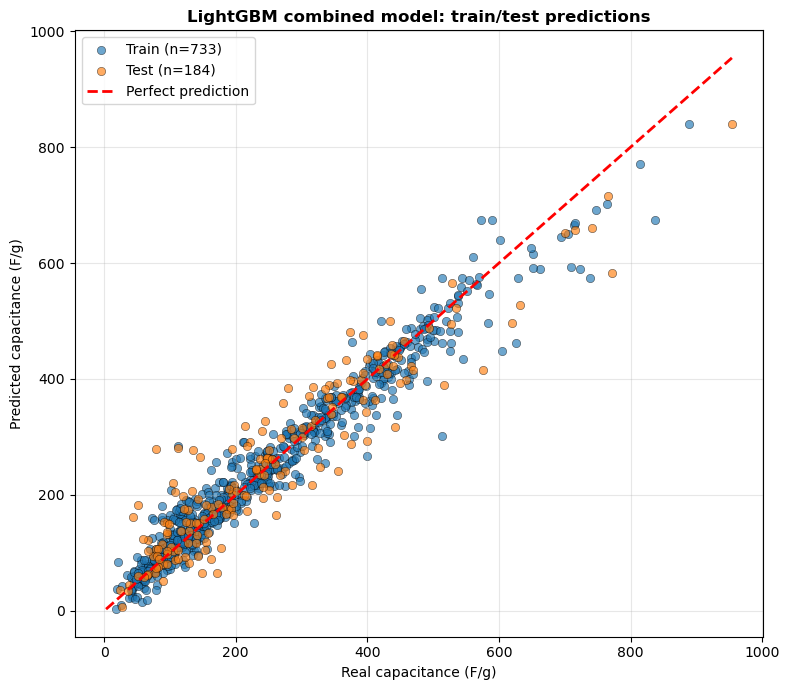

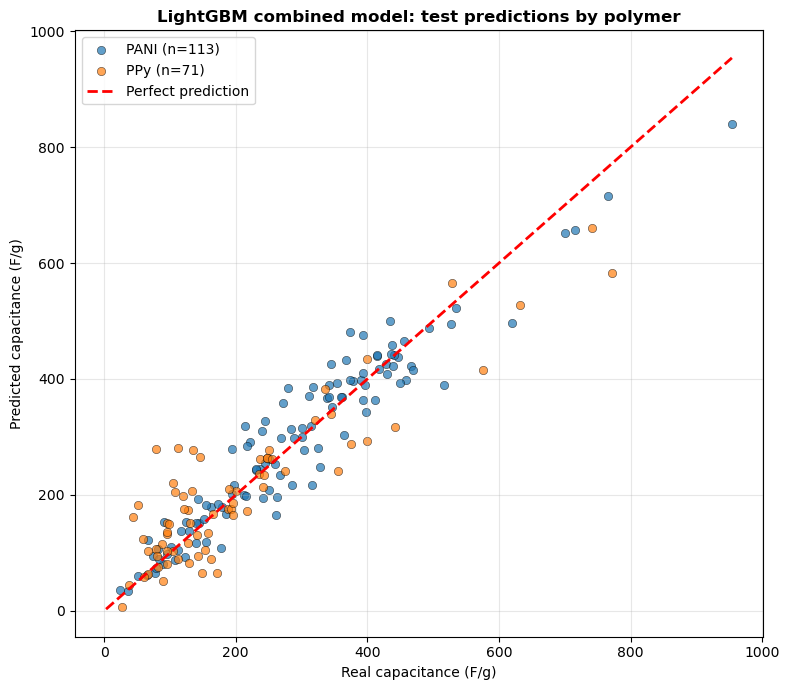


Saved model and evaluation outputs to: Light GBM


In [24]:
y_pred_train = optimized_model.predict(X_train)
y_pred_test = optimized_model.predict(X_test)

def make_prediction_frame(meta_part, split_name, y_true, y_pred):
    out = meta_part.reset_index(drop=True).copy()
    out["Split"] = split_name
    out["Real_Capacitance"] = np.asarray(y_true, dtype=float)
    out["Predicted_Capacitance"] = np.asarray(y_pred, dtype=float)
    out["Absolute_Error"] = (out["Real_Capacitance"] - out["Predicted_Capacitance"]).abs()
    eps = 1e-12
    out["Percentage_Error"] = np.where(
        np.abs(out["Real_Capacitance"]) > eps,
        out["Absolute_Error"] / np.abs(out["Real_Capacitance"]) * 100,
        np.nan,
    )
    return out

train_results_df = make_prediction_frame(meta_train, "Train", y_train, y_pred_train)
test_results_df = make_prediction_frame(meta_test, "Test", y_test, y_pred_test)
prediction_df = pd.concat([train_results_df, test_results_df], ignore_index=True)

metrics_df = build_metrics_table(prediction_df)
print("\n" + "=" * 70)
print("MODEL PERFORMANCE — ONE COMBINED LIGHTGBM MODEL")
print("=" * 70)
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

r2_gap = metrics_df[(metrics_df["Split"] == "Train-Test gap") & (metrics_df["Scope"] == "Combined")]["R2"].iloc[0]
rmse_gap = metrics_df[(metrics_df["Split"] == "Train-Test gap") & (metrics_df["Scope"] == "Combined")]["RMSE"].iloc[0]

if pd.notna(r2_gap) and r2_gap > 0.10:
    print(f"\n⚠ Possible overfitting: Train-Test R² gap = {r2_gap:.4f}; Test-Train RMSE gap = {rmse_gap:.4f}")
else:
    print(f"\n✓ Generalization check acceptable: Train-Test R² gap = {r2_gap:.4f}")

plot_prediction_parity(prediction_df, OUTPUT_DIR)

with open(OUTPUT_DIR / "LGBM_combined_model.pkl", "wb") as f:
    pickle.dump(optimized_model, f)
optimized_model.booster_.save_model(str(OUTPUT_DIR / "LGBM_combined_model.txt"))

cv_results_to_save = cv_results.copy().sort_values("penalized_score", ascending=False) if not cv_results.empty else pd.DataFrame()
cv_cols = [
    "rank_test_score", "mean_test_score", "std_test_score",
    "mean_train_score", "std_train_score", "overfit_gap", "penalized_score", "params"
]
cv_cols = [c for c in cv_cols if c in cv_results_to_save.columns]

with pd.ExcelWriter(OUTPUT_DIR / "LGBM_Combined_Results.xlsx", engine="openpyxl") as writer:
    train_results_df.to_excel(writer, sheet_name="Train_Results", index=False)
    test_results_df.to_excel(writer, sheet_name="Test_Results", index=False)
    prediction_df.to_excel(writer, sheet_name="Train_Test_Results", index=False)
    metrics_df.to_excel(writer, sheet_name="Performance_Metrics", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="Optimized_Parameters", index=False)
    pd.DataFrame([{
        "Best_Penalized_CV_R2": best_penalized,
        "Best_Mean_CV_R2_Test": best_mean_test,
        "Best_Std_CV_R2_Test": best_std_test,
        "Best_Mean_CV_R2_Train": best_mean_train,
        "Best_CV_Overfit_Gap": best_gap,
        "Alpha_Overfit_Gap": ALPHA_OVERFIT_GAP,
        "Split_Description": split_description,
        "CV_Description": cv_description,
    }]).to_excel(writer, sheet_name="GridSearchCV_Summary", index=False)
    if not cv_results_to_save.empty:
        cv_results_to_save[cv_cols].head(300).to_excel(writer, sheet_name="GridSearch_Top300", index=False)
    split_assignment.to_excel(writer, sheet_name="Split_Assignment", index=False)

print(f"\nSaved model and evaluation outputs to: {OUTPUT_DIR}")
